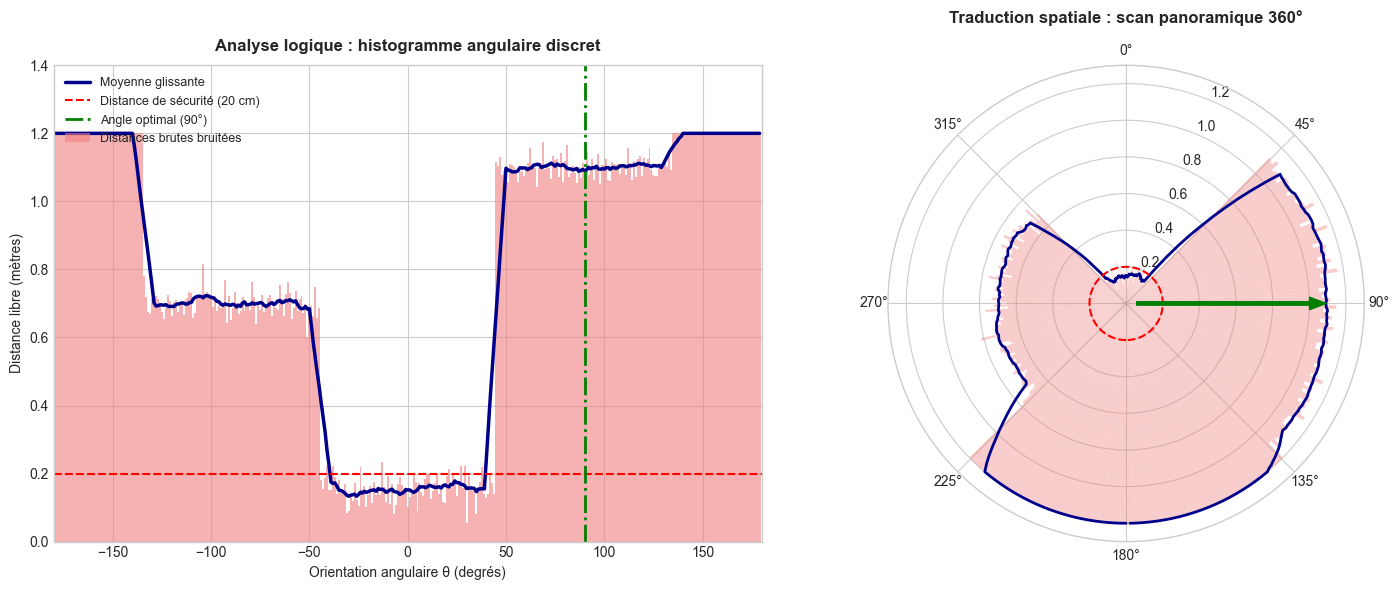

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration du style
plt.style.use(
    'seaborn-v0_8-whitegrid'
    if 'seaborn-v0_8-whitegrid' in plt.style.available
    else 'default'
)

fig = plt.figure(figsize=(15, 6))

# Sous-graphiques
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='polar')

# Génération de données simulant un scan 360°
np.random.seed(42)

# 360 points → 1 point par degré
angles = np.linspace(-180, 180, 360, endpoint=False)
angles_rad = np.radians(angles)

# Distances par défaut
distances_brutes = 1.2 * np.ones_like(angles)

# Obstacle frontal
mask_obstacle = (angles > -45) & (angles < 45)
distances_brutes[mask_obstacle] = (
    0.16 + 0.04 * np.random.randn(np.sum(mask_obstacle))
)

# Couloir dégagé à droite
mask_droite = (angles >= 45) & (angles < 135)
distances_brutes[mask_droite] = (
    1.1 + 0.03 * np.random.randn(np.sum(mask_droite))
)

# Ouverture plus étroite à gauche
mask_gauche = (angles <= -45) & (angles > -135)
distances_brutes[mask_gauche] = (
    0.7 + 0.03 * np.random.randn(np.sum(mask_gauche))
)

# Filtre moyenne glissante
window_size = 11
kernel = np.ones(window_size) / window_size

# Padding pour éviter les artefacts de bord
padded = np.pad(distances_brutes, (window_size // 2,), mode='edge')
distances_lisses = np.convolve(padded, kernel, mode='valid')

# Angle optimal
angle_optimal_deg = 90
angle_optimal_rad = np.radians(angle_optimal_deg)

# =========================================================
# GRAPHIQUE 1 : Histogramme angulaire rectiligne
# =========================================================
ax1.bar(
    angles,
    distances_brutes,
    width=1.0,
    color='lightcoral',
    alpha=0.6,
    label='Distances brutes bruitées'
)

ax1.plot(
    angles,
    distances_lisses,
    color='darkblue',
    linewidth=2.5,
    label='Moyenne glissante'
)

ax1.axhline(
    y=0.20,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Distance de sécurité (20 cm)'
)

ax1.axvline(
    x=angle_optimal_deg,
    color='green',
    linestyle='-.',
    linewidth=2,
    label=f'Angle optimal ({angle_optimal_deg}°)'
)

ax1.set_title(
    "Analyse logique : histogramme angulaire discret",
    fontsize=12,
    fontweight='bold',
    pad=10
)

ax1.set_xlabel("Orientation angulaire θ (degrés)", fontsize=10)
ax1.set_ylabel("Distance libre (mètres)", fontsize=10)

ax1.set_xlim(-180, 180)
ax1.set_ylim(0, 1.4)

ax1.legend(loc='upper left', fontsize=9)

# =========================================================
# GRAPHIQUE 2 : Représentation polaire
# =========================================================
ax2.bar(
    angles_rad,
    distances_brutes,
    width=np.radians(1),
    color='lightcoral',
    alpha=0.4
)

ax2.plot(
    angles_rad,
    distances_lisses,
    color='darkblue',
    linewidth=2
)

# Cercle de sécurité
r_securite = 0.20 * np.ones_like(angles_rad)

ax2.plot(
    angles_rad,
    r_securite,
    color='red',
    linestyle='--',
    linewidth=1.5
)

# Flèche direction optimale
ax2.annotate(
    '',
    xy=(angle_optimal_rad, 1.15),
    xytext=(0, 0),
    arrowprops=dict(
        facecolor='green',
        edgecolor='green',
        shrink=0.05,
        width=2.5,
        headwidth=9
    )
)

ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

ax2.set_title(
    "Traduction spatiale : scan panoramique 360°",
    fontsize=12,
    fontweight='bold',
    pad=15
)

ax2.set_rmax(1.3)

# Sauvegarde
plt.tight_layout()
plt.savefig('histogramme_evitement_rover.png', dpi=300)

# Affichage optionnel
plt.show()

plt.close()